José Herrera Ortiz - Universidad Pontificia Comillas ICAI

# Task 3: Unsupervised learning

In this section, unsupervised learning is used as an exploratory tool to identify latent structure in the student dataset.

Following the course material, the analysis is divided into two complementary parts:

1. **Dimensionality reduction with PCA**, in order to obtain a lower-dimensional representation of the data and improve visualization.
2. **Clustering**, in order to detect groups of students with similar profiles.

Because unsupervised learning is inherently more subjective than supervised learning, there is no universally accepted cross-validation strategy. Therefore, model choice is based on interpretability, internal consistency and visual inspection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

from utils_project import (
    load_data,
    get_project_variables,
    build_unsupervised_data
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

Load data and build unsupervised dataset

In [2]:
df = load_data("../data/rendimiento_estudiantes.csv")
variables = get_project_variables(df)

X_unsup = build_unsupervised_data(df, variables)

print("Shape:", X_unsup.shape)
print("Selected features:")
print(variables["unsupervised_features"])

X_unsup.head()

Shape: (4424, 11)
Selected features:
['edad_al_matricularse', 'nota_cualificacion_previa', 'nota_admision', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion', 'tasa_desempleo', 'tasa_inflacion', 'pib']


,edad_al_matricularse,nota_cualificacion_previa,nota_admision,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib
0,20,122.0,127.3,0,0,0,0.000000,0,10.8,1.4,1.74
1,19,160.0,142.5,6,6,6,14.000000,0,13.9,-0.3,0.79
2,19,122.0,124.8,6,0,0,0.000000,0,10.8,1.4,1.74
3,20,122.0,119.6,6,8,6,13.428571,0,9.4,-0.8,-3.12
4,45,100.0,141.5,6,9,5,12.333333,0,13.9,-0.3,0.79


Standarization

In [3]:
scaler_unsup = StandardScaler()
X_unsup_scaled = scaler_unsup.fit_transform(X_unsup)

X_unsup_scaled_df = pd.DataFrame(X_unsup_scaled, columns=X_unsup.columns)
X_unsup_scaled_df.head()

,edad_al_matricularse,nota_cualificacion_previa,nota_admision,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib
0,-0.430363,-0.804841,0.022229,-2.528560,-1.986068,-1.521257,-2.197102,-0.199273,-0.287638,0.124386,0.765761
1,-0.562168,2.076819,1.071926,-0.109105,-0.550192,0.418050,0.693599,-0.199273,0.876222,-1.105222,0.347199
2,-0.562168,-0.804841,-0.150419,-0.109105,-1.986068,-1.521257,-2.197102,-0.199273,-0.287638,0.124386,0.765761
3,-0.430363,-0.804841,-0.509526,-0.109105,-0.071567,0.418050,0.575611,-0.199273,-0.813253,-1.466871,-1.375511
4,2.864765,-2.473171,1.002867,-0.109105,0.167746,0.094832,0.349468,-0.199273,0.876222,-1.105222,0.347199


## 1. PCA

In [4]:
pca = PCA()
X_pca = pca.fit_transform(X_unsup_scaled)

explained_variance = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,PC,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.251461,0.251461
1,PC2,0.150583,0.402044
2,PC3,0.130762,0.532806
3,PC4,0.104246,0.637053
4,PC5,0.094055,0.731108
5,PC6,0.086167,0.817275
6,PC7,0.053945,0.871220
7,PC8,0.046593,0.917813
8,PC9,0.037624,0.955437
9,PC10,0.035264,0.990701


Scree plot + cumulative variance

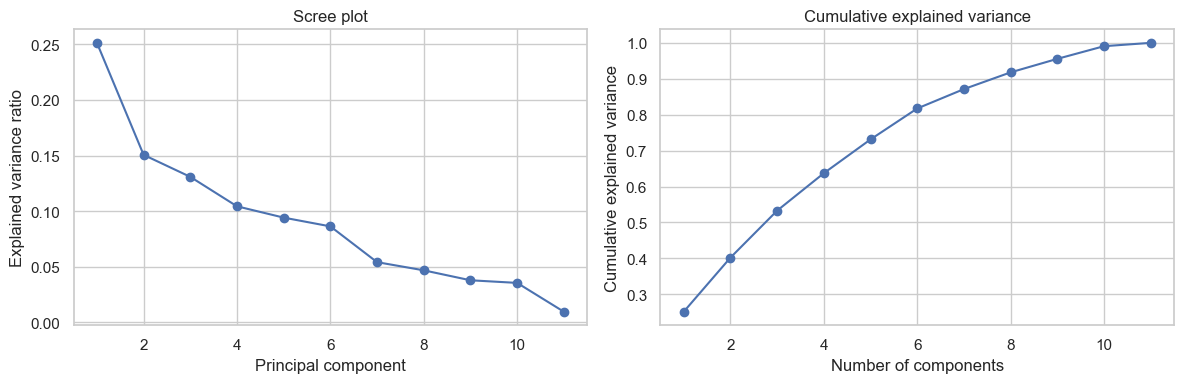

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
ax[0].set_title("Scree plot")
ax[0].set_xlabel("Principal component")
ax[0].set_ylabel("Explained variance ratio")

ax[1].plot(
    range(1, len(np.cumsum(pca.explained_variance_ratio_)) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)
ax[1].set_title("Cumulative explained variance")
ax[1].set_xlabel("Number of components")
ax[1].set_ylabel("Cumulative explained variance")

plt.tight_layout()
plt.show()

PCA 2D Projection

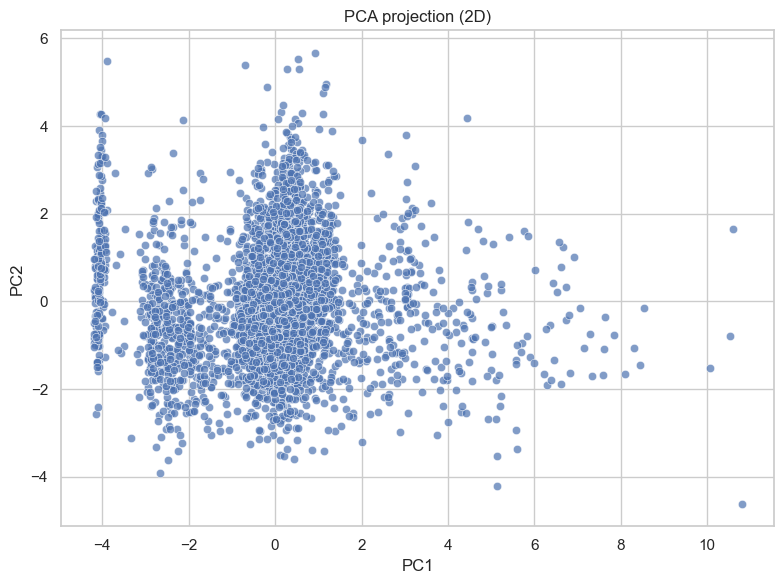

In [6]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_unsup_scaled)

pca_plot_df = pd.DataFrame({
    "PC1": X_pca_2d[:, 0],
    "PC2": X_pca_2d[:, 1]
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot_df, x="PC1", y="PC2", alpha=0.7)
plt.title("PCA projection (2D)")
plt.tight_layout()
plt.show()

PCA loadings

In [7]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X_unsup.columns,
    columns=["PC1", "PC2"]
)

loadings.sort_values("PC1", ascending=False)

,PC1,PC2
asignaturas_1sem_aprobadas,0.541796,0.088027
asignaturas_1sem_matriculadas,0.523772,-0.089168
asignaturas_1sem_evaluadas,0.481541,-0.145216
nota_media_1sem,0.433519,0.151839
asignaturas_1sem_sin_evaluacion,0.085127,-0.104169
tasa_desempleo,0.052769,0.088503
edad_al_matricularse,0.029328,-0.239370
nota_admision,0.013982,0.650041
nota_cualificacion_previa,0.006413,0.663796
tasa_inflacion,-0.002310,-0.014868


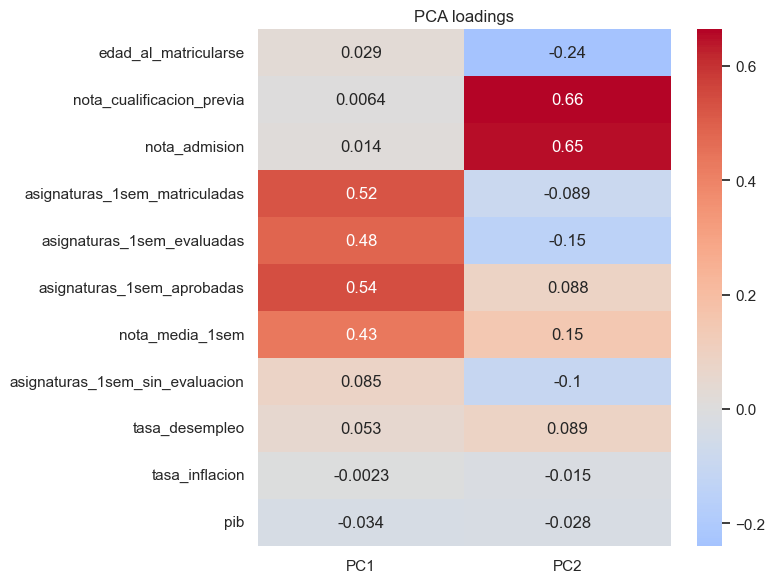

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.title("PCA loadings")
plt.tight_layout()
plt.show()

## 2. K-MEANS

Choose the number of clusters (elbow + silhouette)

In [9]:
k_values = range(2, 9)
kmeans_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_unsup_scaled)

    kmeans_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette": silhouette_score(X_unsup_scaled, labels)
    })

kmeans_results = pd.DataFrame(kmeans_results)
kmeans_results

,k,inertia,silhouette
0,2,40810.113326,0.292386
1,3,36205.419991,0.301129
2,4,32549.791010,0.192907
3,5,29868.080989,0.178807
4,6,27435.493319,0.186533
5,7,25658.158838,0.189936
6,8,24090.456260,0.185204


Elbow + silhouette plots

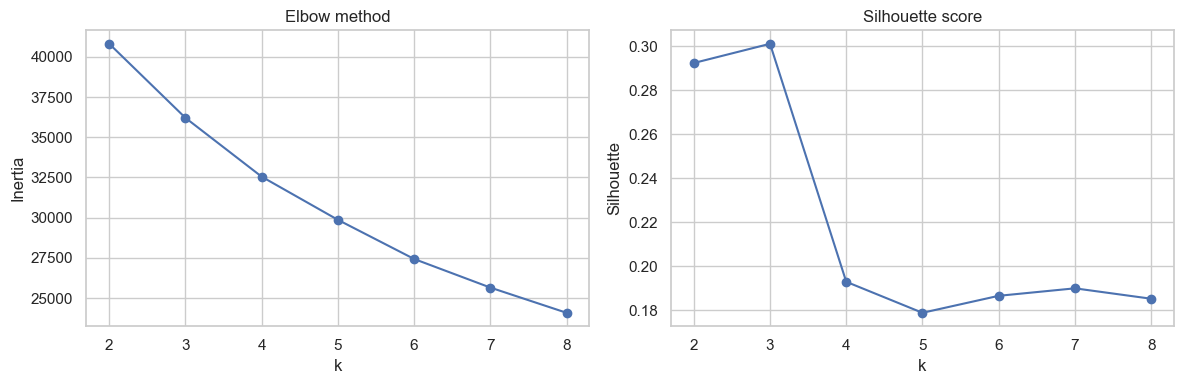

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
ax[0].set_title("Elbow method")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(kmeans_results["k"], kmeans_results["silhouette"], marker="o")
ax[1].set_title("Silhouette score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

Final K-Means

In [11]:
best_k = 3

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
cluster_kmeans = kmeans_final.fit_predict(X_unsup_scaled)

print("Final silhouette:", silhouette_score(X_unsup_scaled, cluster_kmeans))

Final silhouette: 0.3011288808133327


PCA plot colored by sizes

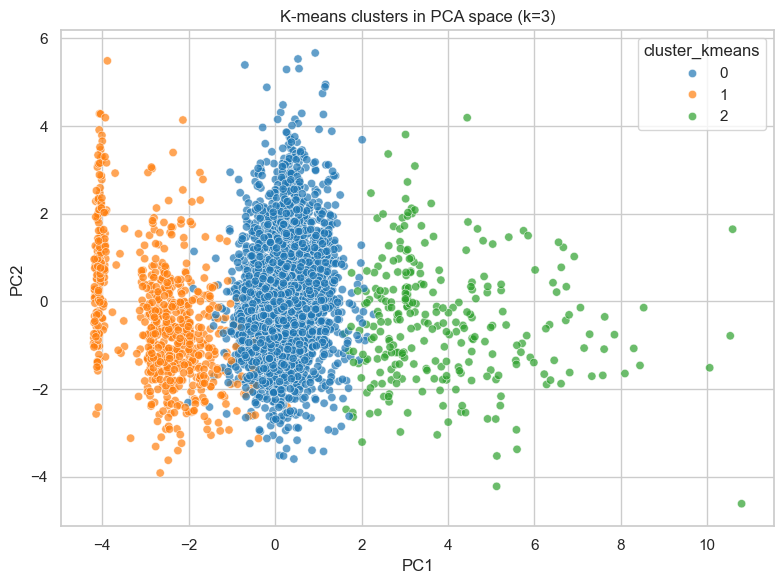

In [12]:
pca_plot_df["cluster_kmeans"] = cluster_kmeans

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster_kmeans",
    palette="tab10",
    alpha=0.7
)
plt.title(f"K-means clusters in PCA space (k={best_k})")
plt.tight_layout()
plt.show()

Cluster sizes

In [13]:
pd.Series(cluster_kmeans).value_counts().sort_index()

0    3425
1     720
2     279
Name: count, dtype: int64

Cluster profiles

In [14]:
X_kmeans_profile_scaled = X_unsup_scaled_df.copy()
X_kmeans_profile_scaled["cluster"] = cluster_kmeans

cluster_profile_scaled = X_kmeans_profile_scaled.groupby("cluster").mean().round(2)
cluster_profile_scaled

,edad_al_matricularse,nota_cualificacion_previa,nota_admision,asignaturas_1sem_matriculadas,asignaturas_1sem_evaluadas,asignaturas_1sem_aprobadas,nota_media_1sem,asignaturas_1sem_sin_evaluacion,tasa_desempleo,tasa_inflacion,pib
cluster,,,,,,,,,,,
0,-0.13,0.01,-0.01,-0.05,0.06,0.14,0.43,-0.07,0.00,-0.02,0.03
1,0.32,0.01,-0.01,-0.85,-1.07,-1.52,-2.19,0.17,0.00,0.06,-0.10
2,0.81,-0.08,0.19,2.80,2.07,2.23,0.41,0.48,-0.06,0.14,-0.12


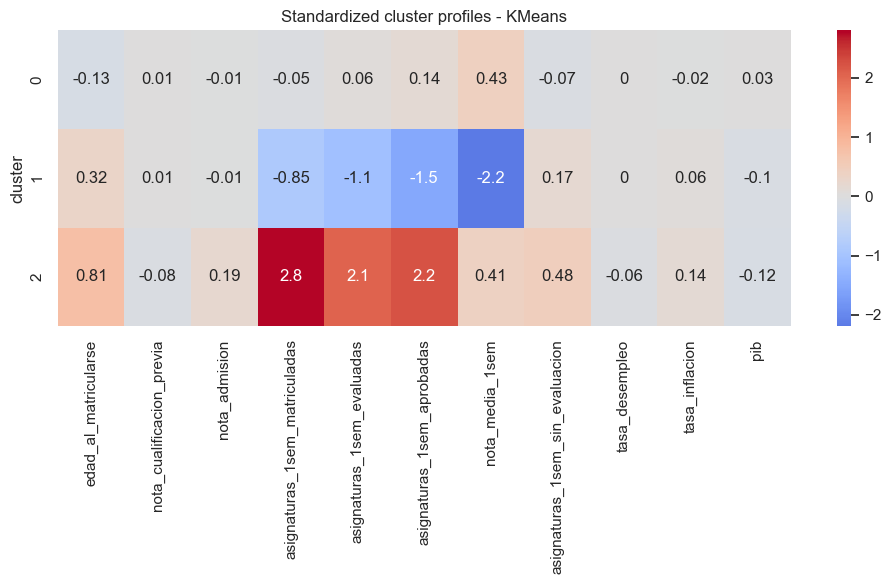

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Standardized cluster profiles - KMeans")
plt.tight_layout()
plt.show()

## 3. Hierarchical Clustering

Dendrogram with Ward linkage

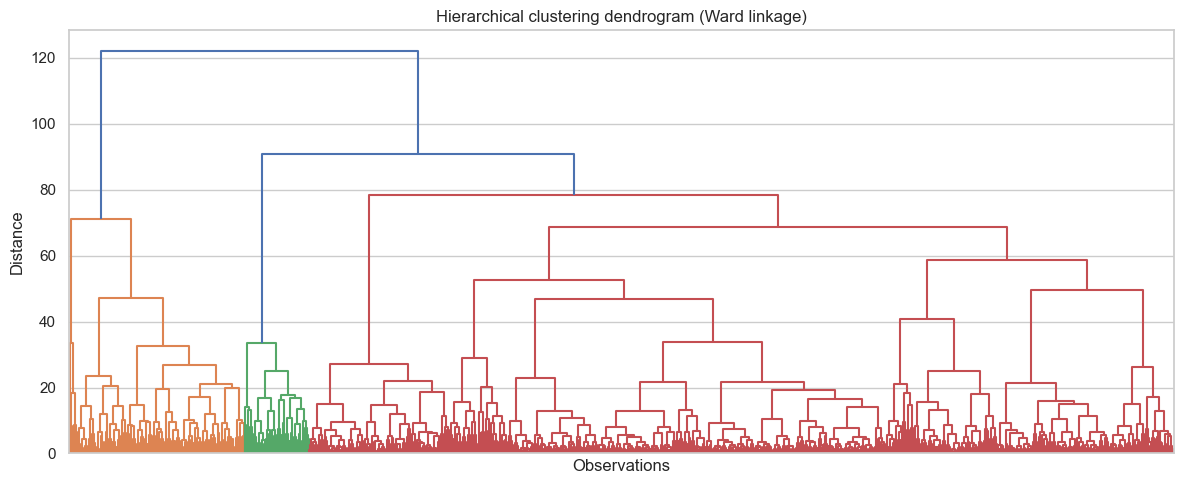

In [16]:
Z = linkage(X_unsup_scaled, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True, color_threshold=None)
plt.title("Hierarchical clustering dendrogram (Ward linkage)")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

Agglomerative clustering

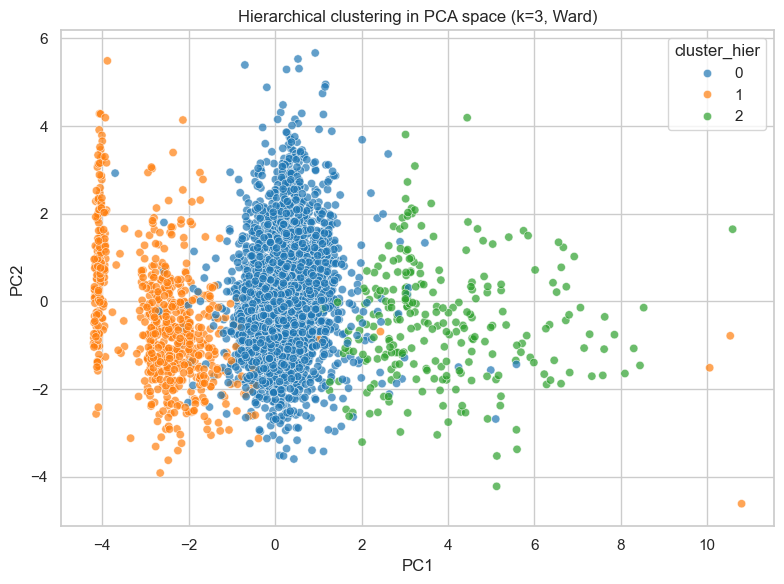

In [17]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
cluster_hier = agg.fit_predict(X_unsup_scaled)

pca_plot_df["cluster_hier"] = cluster_hier

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="cluster_hier",
    palette="tab10",
    alpha=0.7
)
plt.title(f"Hierarchical clustering in PCA space (k={best_k}, Ward)")
plt.tight_layout()
plt.show()

## 4. Ex Post interpretation with `objetivo`

Compare clusters with final status

In [18]:
df_unsup = df.copy()
df_unsup["cluster_kmeans"] = cluster_kmeans
df_unsup["cluster_hier"] = cluster_hier

cluster_vs_target_kmeans = pd.crosstab(
    df_unsup["cluster_kmeans"],
    df_unsup["objetivo"],
    normalize="index"
).round(3)

cluster_vs_target_kmeans

objetivo,abandono,graduado,matriculado
cluster_kmeans,,,
0,0.229,0.571,0.201
1,0.794,0.107,0.099
2,0.237,0.638,0.125


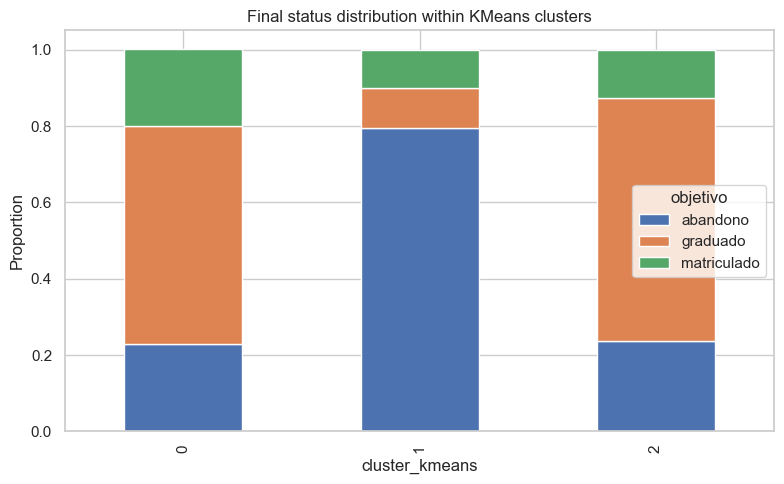

In [19]:
cluster_vs_target_kmeans.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.title("Final status distribution within KMeans clusters")
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()